In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [4]:
proliferative_aois=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Data/proliferative_aois.csv")

metadata=pd.read_csv("/Volumes/h30492/farkkilab2/9_EyeMT/Data/geomx/batch123/metadata/dcc_metadata_batch123_cleaned.csv")

In [ ]:
proliferative_aois.merge

In [6]:
metadata = metadata.rename(columns={'dcc_filename': 'dcc_filename_1'})

# 3. Merge on 'dcc_filename_1'
# Default is an 'inner' merge; use how='left' if you want to keep all rows from proliferative_aois
merged_df = pd.merge(proliferative_aois, metadata, on='dcc_filename_1')

# Display the first few rows to verify


In [10]:
merged_df["Segment"].unique()

array(['tumor'], dtype=object)

In [11]:
ssgsea_scores=pd.read_csv("/Volumes/h30492/farkkilab2/9_EyeMT/Data_analysis/geomx_processing/batch123-2808/pathway_analysis/gsea/ssgsea_norm_harmony_batch_corr_q3_norm_all_msigdb.csv")

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_25857/1998182840.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  ssgsea_scores=pd.read_csv("/Volumes/h30492/farkkilab2/9_EyeMT/Data_analysis/geomx_processing/batch123-2808/pathway_analysis/gsea/ssgsea_norm_harmony_batch_corr_q3_norm_all_msigdb.csv")


In [18]:

wide_ssgsea =ssgsea_scores.pivot(
    index=["dcc_filename", "Sample"],
    columns="pathway",
    values="ssgsea_score"
)

wide_ssgsea.index = wide_ssgsea.index.rename(["dcc_filename_1", "Sample"])
wide_ssgsea =wide_ssgsea.reset_index()
wide_ssgsea["dcc_filename_1"] = wide_ssgsea["dcc_filename_1"].astype(str)
#wide_hallmark_ssgsea["Sample"] = wide_hallmark_ssgsea["Sample"].astype(str)
merged_df_ssgsea = pd.merge(
    wide_ssgsea,
    proliferative_aois,
    on="dcc_filename_1",
    how="inner"
)

Random Forest selected 3100 pathways.


/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


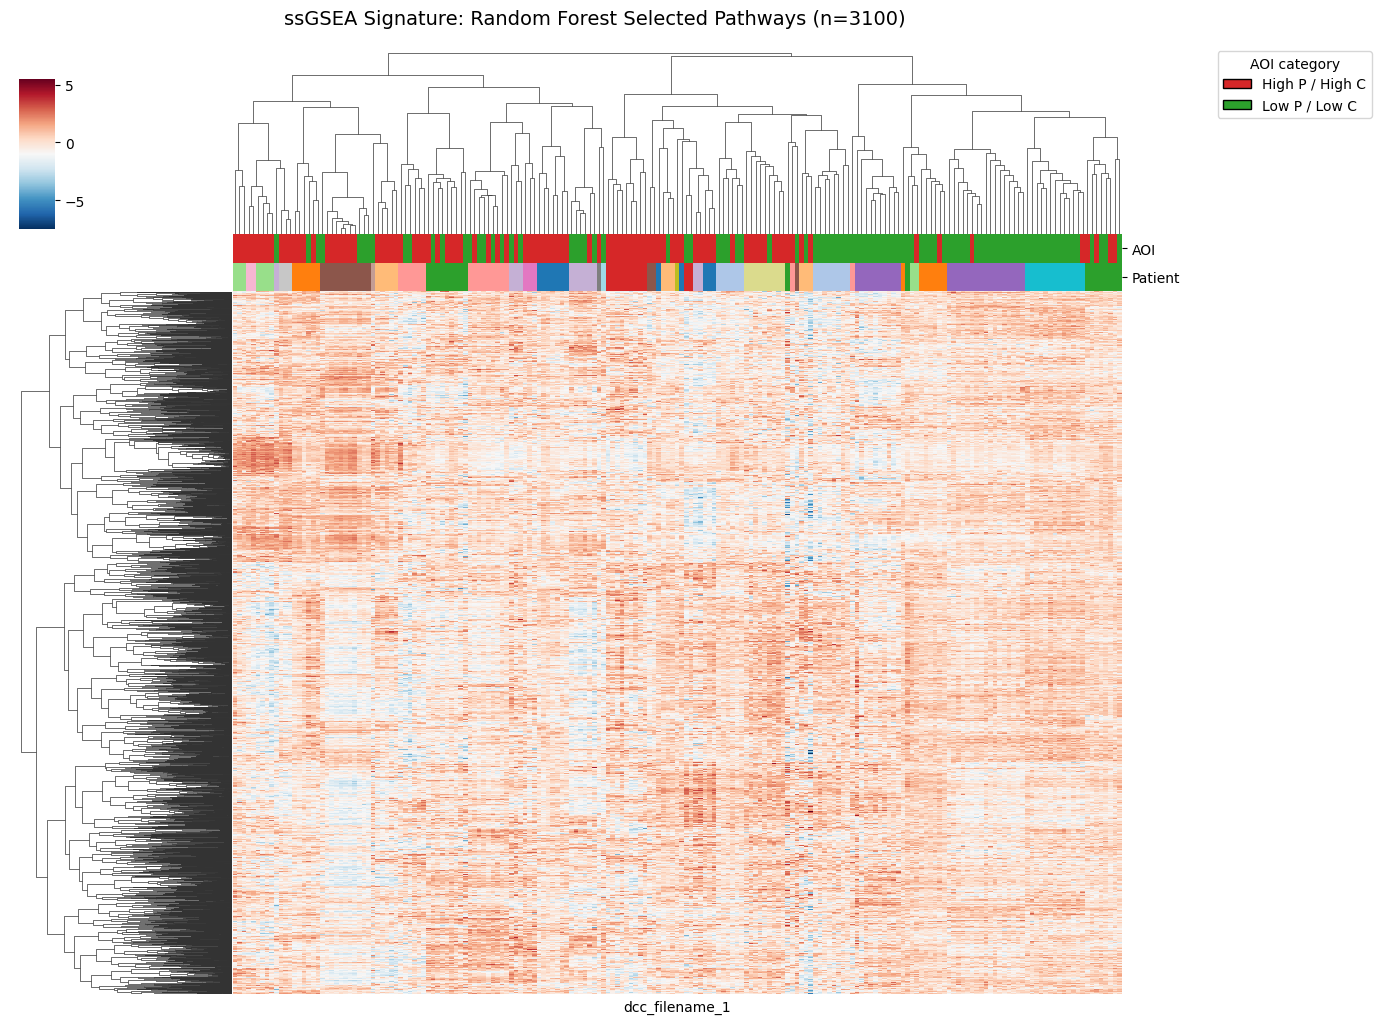

In [19]:

# ---------------------------# 1. Identify Pathway Columns & Metadata
# -----------------------------
all_ssgsea_pathways = wide_ssgsea.columns.difference(["dcc_filename_1", "Sample"]).tolist()

# -----------------------------
# 2. Filter for specific categories FIRST
# -----------------------------
target_categories = ["High P / High C", "Low P / Low C"]
df_filtered = merged_df_ssgsea[merged_df_ssgsea["AOI_category"].isin(target_categories)].copy()

# Ensure pathway data is numeric
df_filtered[all_ssgsea_pathways] = df_filtered[all_ssgsea_pathways].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

# -----------------------------
# 3. Random Forest Feature Selection
# -----------------------------
X = df_filtered[all_ssgsea_pathways]
y = df_filtered["AOI_category"]

# Fit Random Forest to find predictive features
rf = RandomForestClassifier(n_estimators=2000, random_state=42, class_weight='balanced')
rf.fit(X, y)

# Extract importance scores
importances = pd.Series(rf.feature_importances_, index=all_ssgsea_pathways)

# Filter: Keep pathways with importance above the mean
threshold = importances.median() 

#top_n = 500
#top_pathways_rf = importances.head(top_n).index
top_pathways_rf = importances[importances >= threshold].sort_values(ascending=False).index
print(f"Random Forest selected {len(top_pathways_rf)} pathways.")
#print(f"Random Forest selected {len(top_pathways_rf)} pathways.")

# -----------------------------
# 4. Prepare Matrix
# -----------------------------
data = df_filtered.set_index("dcc_filename_1")[top_pathways_rf].T

# -----------------------------
# 5. Annotation Colors
# -----------------------------
palette = {
    "High P / High C": "#d62728",
    "Low P / Low C": "#2ca02c"
}

sample_col = "Sample_x" if "Sample_x" in df_filtered.columns else "Sample"
unique_samples = df_filtered[sample_col].unique()
sample_pal = dict(zip(unique_samples, sns.color_palette("tab20", len(unique_samples))))

col_colors = pd.DataFrame({
    "AOI": df_filtered.set_index("dcc_filename_1")["AOI_category"].map(palette),
    "Patient": df_filtered.set_index("dcc_filename_1")[sample_col].map(sample_pal)
})

# -----------------------------
# 6. CLUSTERMAP (Labels Removed)
# -----------------------------
g = sns.clustermap(
    data,
    col_colors=col_colors,
    row_cluster=True,
    col_cluster=True,
    z_score=0,             
    cmap="RdBu_r",
    figsize=(12, 10),      
    xticklabels=False,     # No AOI names
    yticklabels=False, 
    #method="ward",
    #metric="euclidean",
    method="complete",
    metric="correlation",
    cbar_pos=(0.02, 0.8, 0.03, 0.15) 
)

# -----------------------------
# 7. Legend
# -----------------------------
handles = [
    Patch(facecolor=palette[label], edgecolor="black", label=label)
    for label in target_categories
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="AOI category",
    loc="upper left",
    bbox_to_anchor=(1.1, 1),
    frameon=True
)

g.fig.suptitle(f"ssGSEA Signature: Random Forest Selected Pathways (n={len(top_pathways_rf)})", y=1.02, fontsize=14)

plt.show()

/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


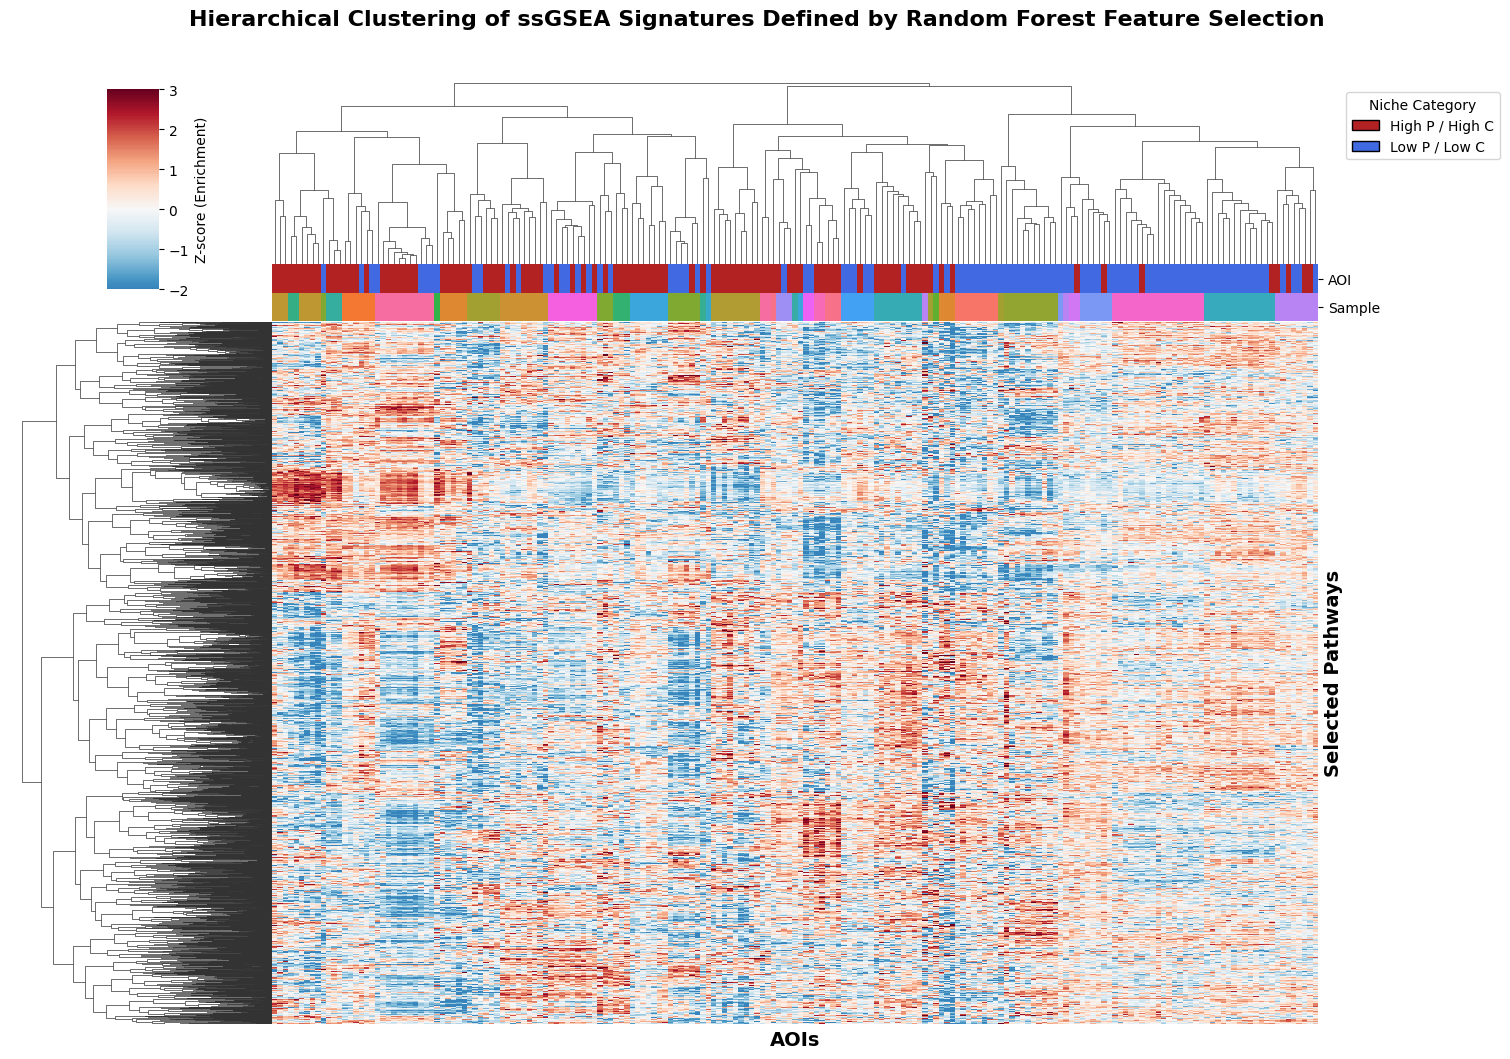

In [48]:
# -----------------------------
# 5. Annotation Colors (Matched EXACTLY to Volcano Code)
# -----------------------------
palette = {
    "High P / High C": "firebrick", 
    "Low P / Low C": "royalblue"
}

sample_col = "Sample_x" if "Sample_x" in df_filtered.columns else "Sample"
unique_samples = df_filtered[sample_col].unique()
sample_pal = dict(zip(unique_samples, sns.color_palette("husl", len(unique_samples))))

col_colors = pd.DataFrame({
    "AOI": df_filtered.set_index("dcc_filename_1")["AOI_category"].map(palette),
    "Sample": df_filtered.set_index("dcc_filename_1")[sample_col].map(sample_pal)
})

# -----------------------------
# 6. CLUSTERMAP
# -----------------------------
g = sns.clustermap(
    data,
    col_colors=col_colors,
    row_cluster=True,
    col_cluster=True,
    vmin=-2,
    vmax=3,
    z_score=0,             
    cmap="RdBu_r",         
    center=0,
    figsize=(14, 10),      
    xticklabels=False,     
    yticklabels=False, 
    method="complete",
    metric="correlation",
    cbar_kws={'label': 'Z-score (Enrichment)'},
    cbar_pos=(0.08, 0.77, 0.037, 0.2) 
)

# Set Axis Labels
g.ax_heatmap.set_xlabel("AOIs", fontsize=14, fontweight='bold')
g.ax_heatmap.set_ylabel("Selected Pathways", fontsize=14, fontweight='bold')

# -----------------------------
# 7. Legend & Title
# -----------------------------
from matplotlib.patches import Patch
handles = [
    Patch(facecolor=palette[label], edgecolor="black", label=label)
    for label in target_categories
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="Niche Category",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.94),
    frameon=True
)

g.fig.suptitle("                Hierarchical Clustering of ssGSEA Signatures Defined by Random Forest Feature Selection", 
               y=1.05, fontsize=16, fontweight='bold')

plt.show()

/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


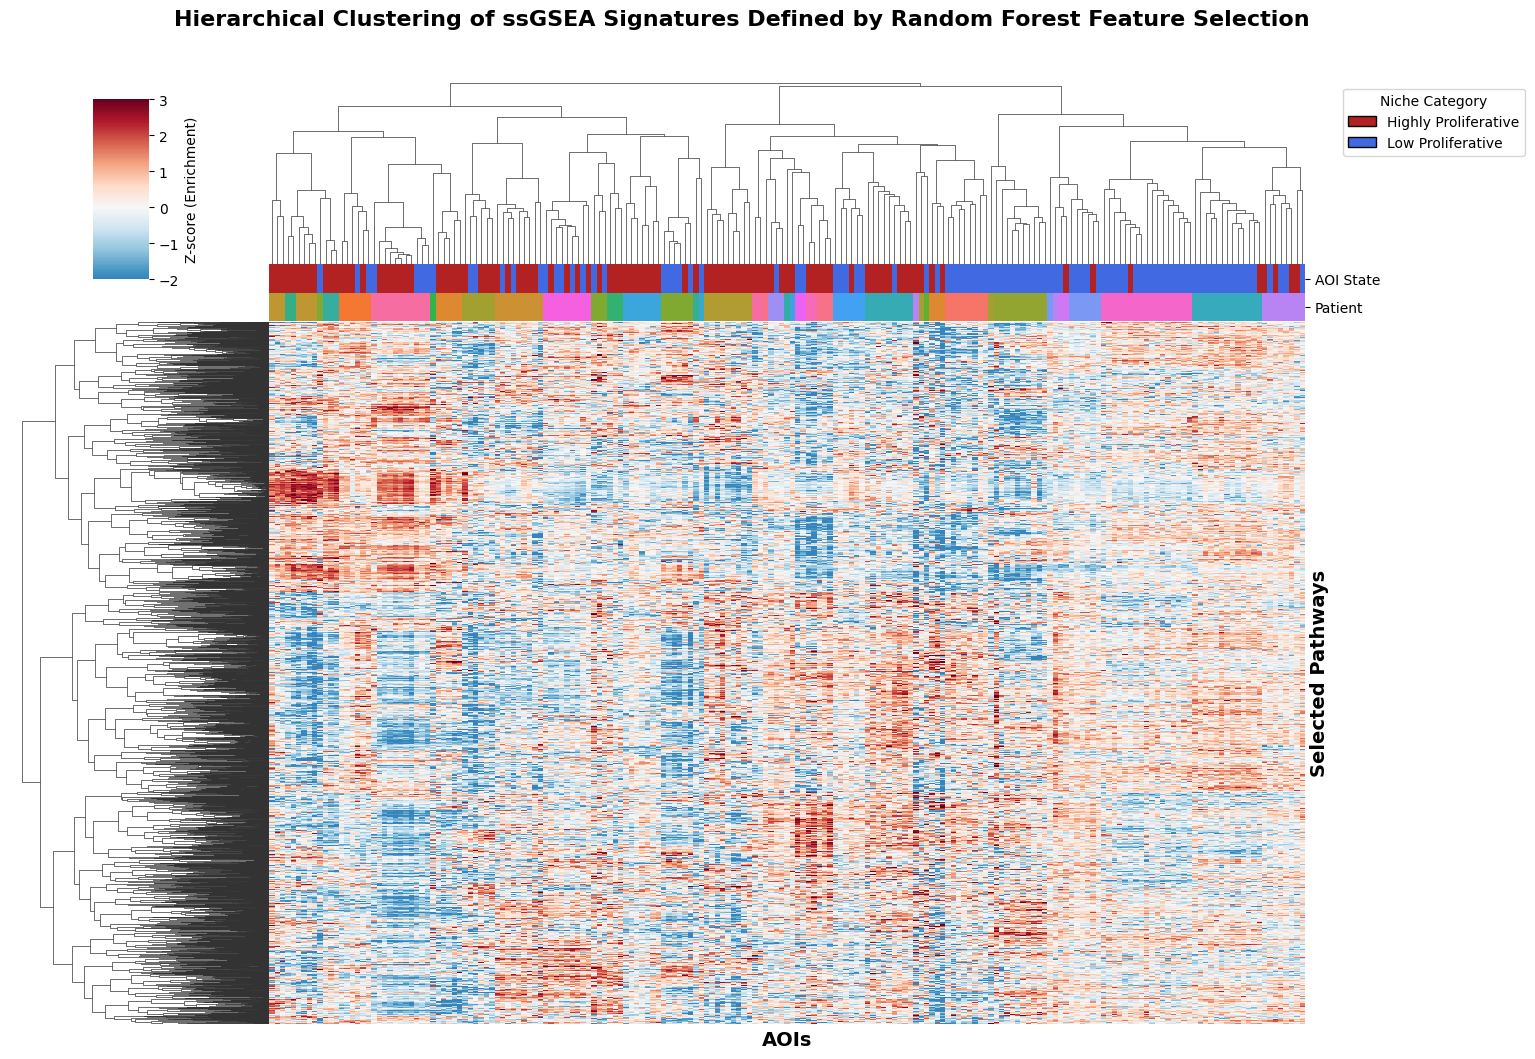

In [60]:
# -----------------------------
# 5. Annotation Colors & Labels
# -----------------------------
# Mapping for the legend display only
display_mapping = {
    "High P / High C": "Highly Proliferative",
    "Low P / Low C": "Low Proliferative"
}

palette = {
    "High P / High C": "firebrick", 
    "Low P / Low C": "royalblue"
}

sample_col = "Sample_x" if "Sample_x" in df_filtered.columns else "Sample"
unique_samples = df_filtered[sample_col].unique()
sample_pal = dict(zip(unique_samples, sns.color_palette("husl", len(unique_samples))))

col_colors = pd.DataFrame({
    "AOI State": df_filtered.set_index("dcc_filename_1")["AOI_category"].map(palette),
    "Patient": df_filtered.set_index("dcc_filename_1")[sample_col].map(sample_pal)
})

# -----------------------------
# 6. CLUSTERMAP
# -----------------------------
g = sns.clustermap(
    data,
    col_colors=col_colors,
    row_cluster=True,
    col_cluster=True,
    z_score=0,  
    vmin=-2, 
    vmax=3,           
    cmap="RdBu_r",         
    center=0,
    figsize=(14, 10),      
    xticklabels=False,     
    yticklabels=False, 
    method="complete",
    metric="correlation",
    cbar_kws={'label': 'Z-score (Enrichment)'},
    cbar_pos=(0.07, 0.78, 0.04, 0.18) 
)

# Label the axes
g.ax_heatmap.set_xlabel("AOIs", fontsize=14, fontweight='bold')
g.ax_heatmap.set_ylabel("Selected Pathways", fontsize=14, fontweight='bold')

# -----------------------------
# 7. Legend (Renamed manually)
# -----------------------------
from matplotlib.patches import Patch

# We use the original dataframe keys to pull the color, 
# but use the descriptive strings for the 'label'
handles = [
    Patch(facecolor=palette[key], edgecolor="black", label=display_mapping[key])
    for key in palette.keys()
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="Niche Category",
    loc="upper left",
    bbox_to_anchor=(1.03, 0.96),
    frameon=True
)

g.fig.suptitle("            Hierarchical Clustering of ssGSEA Signatures Defined by Random Forest Feature Selection", 
               y=1.05, fontsize=16, fontweight='bold')

plt.show()